In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
import re
from matplotlib.lines import Line2D
import sys
sys.path.append('../../../Code')
from helper_plot import plot_trait_scatter



### Read data

In [2]:
df0 = pd.read_csv('../data/metrics_masks5_plus_full.csv')
df0 = df0.drop(columns=["image_path", "mask_path","scale_max_used"])

df0["Fungal_Strain"] = df0["plate"].str.split("_").str[1]
df0["Nitrogen_Level"] = df0["plate"].str.split("_").str[2]

views = df0['view'].unique()
mask_types = df0['mask_type'].unique()
dates = df0['date'].unique()[1:]

In [3]:
df_resp_0 = pd.read_excel("../data/MV_final_cleaned_combined.xlsx", sheet_name='wide',engine="openpyxl")
df_resp = df_resp_0.copy()
df_resp["plate"] = df_resp["label"]
df_resp = df_resp[["plate", "respiration"]]

df_combined = pd.merge(df0, df_resp, on='plate')
df_combined = df_combined[df_combined["respiration"] <= 5.0]
print(f"After removing outliers, data size: {df_combined.shape}")
df_combined["fungus"] = df_combined["plate"].str.split("_").str[1]
df_combined["nitrogen"] = df_combined["plate"].str.split("_").str[2]



After removing outliers, data size: (3480, 66)


In [4]:
cols = df_combined.columns
RGB_traits = [c for c in cols if re.match(r"^[RGB]_8bit_", c)]
HSV_traits = [c for c in cols if re.match(r"^[HSV]_", c)]
LAB_traits = [c for c in cols if re.match(r"^(L_|A_|LabB_)", c)]
Ncolor_traits = ['area_pixels', 'circularity',
       'contour_count', 'hull_area', 'max_width', 'min_width', 'perimeter',
       'rect_angle_deg', 'solidity']

In [5]:
trait_order = Ncolor_traits + RGB_traits + HSV_traits + LAB_traits


In [6]:
df_combined

,plate,date,view,mask_type,area_pixels,contour_count,perimeter,hull_area,solidity,min_width,...,LabB_min,LabB_max,LabB_mean,LabB_median,LabB_var,Fungal_Strain,Nitrogen_Level,respiration,fungus,nitrogen
0,10_LE_N-1_1_MV.003,2024-12-20,overhead,all,30219,1,685.068104,30844.0,0.979737,193.148041,...,136.0,149.0,144.254012,144.0,3.926212,LE,N-1,2.867785,LE,N-1
1,10_LE_N-1_1_MV.003,2024-12-20,raw,all,30219,1,685.068104,30844.0,0.979737,193.148041,...,128.0,152.0,144.433668,146.0,14.922128,LE,N-1,2.867785,LE,N-1
2,11_FG_N-1_4_MV.003,2024-12-20,overhead,all,20833,1,540.658942,20765.0,1.003275,155.434082,...,129.0,145.0,139.636250,140.0,4.899415,FG,N-1,1.573358,FG,N-1
3,11_FG_N-1_4_MV.003,2024-12-20,raw,all,20833,1,540.658942,20765.0,1.003275,155.434082,...,119.0,151.0,141.564729,143.0,31.154753,FG,N-1,1.573358,FG,N-1
4,12_FG_N-1_5_MV.003,2024-12-20,overhead,all,21511,1,551.185853,21533.5,0.998955,161.473251,...,130.0,146.0,139.385338,140.0,6.191387,FG,N-1,1.369857,FG,N-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3595,7_LE_N-10_2_MV.003,2024-12-31,raw,old_growth,1092349,1,3976.928393,1096287.0,0.996408,1158.568970,...,131.0,151.0,138.989341,138.0,9.401271,LE,N-10,3.091117,LE,N-10
3596,8_FG_N-10_2_MV.003,2024-12-31,overhead,old_growth,1158154,1,4035.597437,1158482.5,0.999716,1210.363281,...,116.0,149.0,143.368085,144.0,5.489435,FG,N-10,2.138982,FG,N-10
3597,8_FG_N-10_2_MV.003,2024-12-31,raw,old_growth,1158154,1,4035.597437,1158482.5,0.999716,1210.363281,...,122.0,160.0,139.863781,140.0,8.307417,FG,N-10,2.138982,FG,N-10
3598,9_LE_N-1_5_MV.003,2024-12-31,overhead,old_growth,1056912,1,3905.229904,1059177.0,0.997862,1156.511230,...,119.0,149.0,135.392944,135.0,5.811898,LE,N-1,0.909891,LE,N-1


### log and normalization

In [7]:
df_combined["log_res"] = np.log1p(df_combined["respiration"])


In [8]:
df_combined.columns

Index(['plate', 'date', 'view', 'mask_type', 'area_pixels', 'contour_count',
       'perimeter', 'hull_area', 'solidity', 'min_width', 'max_width',
       'rect_angle_deg', 'circularity', 'B_8bit_min', 'B_8bit_max',
       'B_8bit_mean', 'B_8bit_median', 'B_8bit_var', 'G_8bit_min',
       'G_8bit_max', 'G_8bit_mean', 'G_8bit_median', 'G_8bit_var',
       'R_8bit_min', 'R_8bit_max', 'R_8bit_mean', 'R_8bit_median',
       'R_8bit_var', 'Gray_8bit_min', 'Gray_8bit_max', 'Gray_8bit_mean',
       'Gray_8bit_median', 'Gray_8bit_var', 'H_min', 'H_max', 'H_mean',
       'H_median', 'H_var', 'S_min', 'S_max', 'S_mean', 'S_median', 'S_var',
       'V_min', 'V_max', 'V_mean', 'V_median', 'V_var', 'L_min', 'L_max',
       'L_mean', 'L_median', 'L_var', 'A_min', 'A_max', 'A_mean', 'A_median',
       'A_var', 'LabB_min', 'LabB_max', 'LabB_mean', 'LabB_median', 'LabB_var',
       'Fungal_Strain', 'Nitrogen_Level', 'respiration', 'fungus', 'nitrogen',
       'log_res'],
      dtype='object')

## Univariate analysis with Respiration

In [9]:
df_raw_new_day24 = df_combined[(df_combined["view"] == "raw") & 
                               (df_combined["mask_type"] == "new_growth") & 
                               (df_combined["date"] == "2024-12-24")]

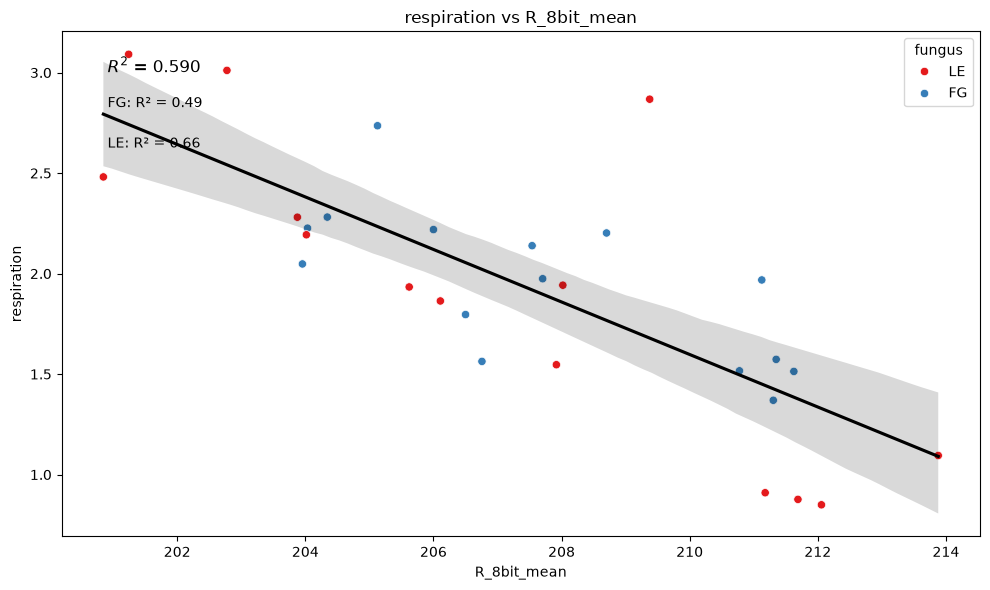

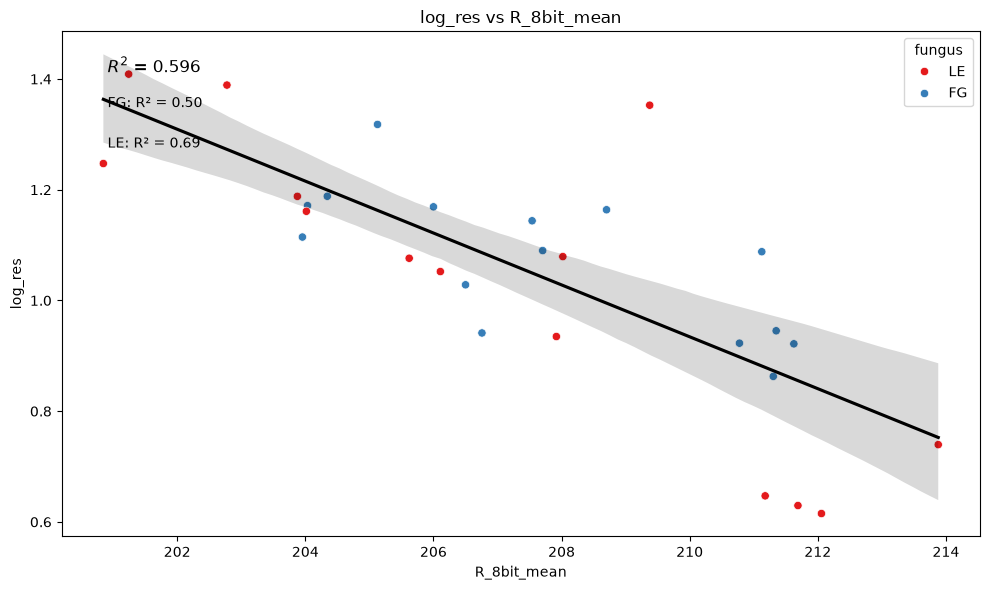

In [10]:
for res in ["respiration","log_res"]:
    plot_trait_scatter(df_raw_new_day24, 'R_8bit_mean', res, hue_col='fungus', per_group_r2=True)

## Analysis of respiration prediction


when we do respiration prediction, we use  CV  based on stratified target method to split the datasets into training and testing.

Split by the target (respiration) so that each fold’s test set contains samples spanning the full target range:

1. Rank samples by respiration.
2. Bin them into K quantile groups (choose K based on sample size, here we use K=6).
3. For each fold, select one sample from each bin for the test set (so the test set has low/medium/high respiration values).

This method balances the target distribution, but it does not guarantee balance across Fungal_Strain × Nitrogen_Level. So a fold could accidentally over/under-represent.


## Analysis （use same outer fold for all data，5 fold）, delete outliers

### whole results 

In [11]:
with open("../results/resp_OUTCVfix_results_4900037.pkl", "rb") as f:
    results_resp_1 = pickle.load(f)

print(type(results_resp_1))  
# this result is same with resp_CV_JOBSupdate_4947538.pkl (4947538 use parallel computing)

<class 'dict'>


In [12]:
results_resp_1.keys()

dict_keys([('overhead', 'all', '2024-12-21'), ('overhead', 'all', '2024-12-22'), ('overhead', 'all', '2024-12-23'), ('overhead', 'all', '2024-12-24'), ('overhead', 'all', '2024-12-25'), ('overhead', 'all', '2024-12-26'), ('overhead', 'all', '2024-12-27'), ('overhead', 'all', '2024-12-28'), ('overhead', 'all', '2024-12-29'), ('overhead', 'all', '2024-12-30'), ('overhead', 'all', '2024-12-31'), ('overhead', 'plug', '2024-12-21'), ('overhead', 'plug', '2024-12-22'), ('overhead', 'plug', '2024-12-23'), ('overhead', 'plug', '2024-12-24'), ('overhead', 'plug', '2024-12-25'), ('overhead', 'plug', '2024-12-26'), ('overhead', 'plug', '2024-12-27'), ('overhead', 'plug', '2024-12-28'), ('overhead', 'plug', '2024-12-29'), ('overhead', 'plug', '2024-12-30'), ('overhead', 'plug', '2024-12-31'), ('overhead', 'all_plug', '2024-12-21'), ('overhead', 'all_plug', '2024-12-22'), ('overhead', 'all_plug', '2024-12-23'), ('overhead', 'all_plug', '2024-12-24'), ('overhead', 'all_plug', '2024-12-25'), ('overhe

#### plot the results across data and models

In [13]:
rows = []
for (view, mask_type, date), v in results_resp_1.items():
    s_rmse = v[2]["mean_rmse"]
    s_mae = v[2]["mean_mae"]
    s_r2 = v[2]["mean_r2"]

    df_tmp = pd.DataFrame({
        "model": s_rmse.index,
        "mean_rmse": s_rmse.values,
        "mean_mae": s_mae.values,
        "mean_r2": s_r2.values
    })

    df_tmp["view"] = view
    df_tmp["mask_type"] = mask_type
    df_tmp["date"] = date

    rows.append(df_tmp)

df_scores_resp_1 = pd.concat(rows, ignore_index=True)

# Reorder columns
df_scores_resp_1 = df_scores_resp_1[["view", "mask_type", "date", "model", "mean_rmse", "mean_mae", "mean_r2"]]

In [14]:
df_scores_resp_1[(df_scores_resp_1["date"]=="2024-12-27") & (df_scores_resp_1["mask_type"]=="new_growth") & (df_scores_resp_1["view"]=="raw")]

,view,mask_type,date,model,mean_rmse,mean_mae,mean_r2
376,raw,new_growth,2024-12-27,RandomForestRegressor,0.475306,0.355765,0.295901
377,raw,new_growth,2024-12-27,PLSRegression,0.549681,0.432043,0.086643
378,raw,new_growth,2024-12-27,Ridge,0.549862,0.443384,0.087636
379,raw,new_growth,2024-12-27,ElasticNet,0.570237,0.462553,0.023884


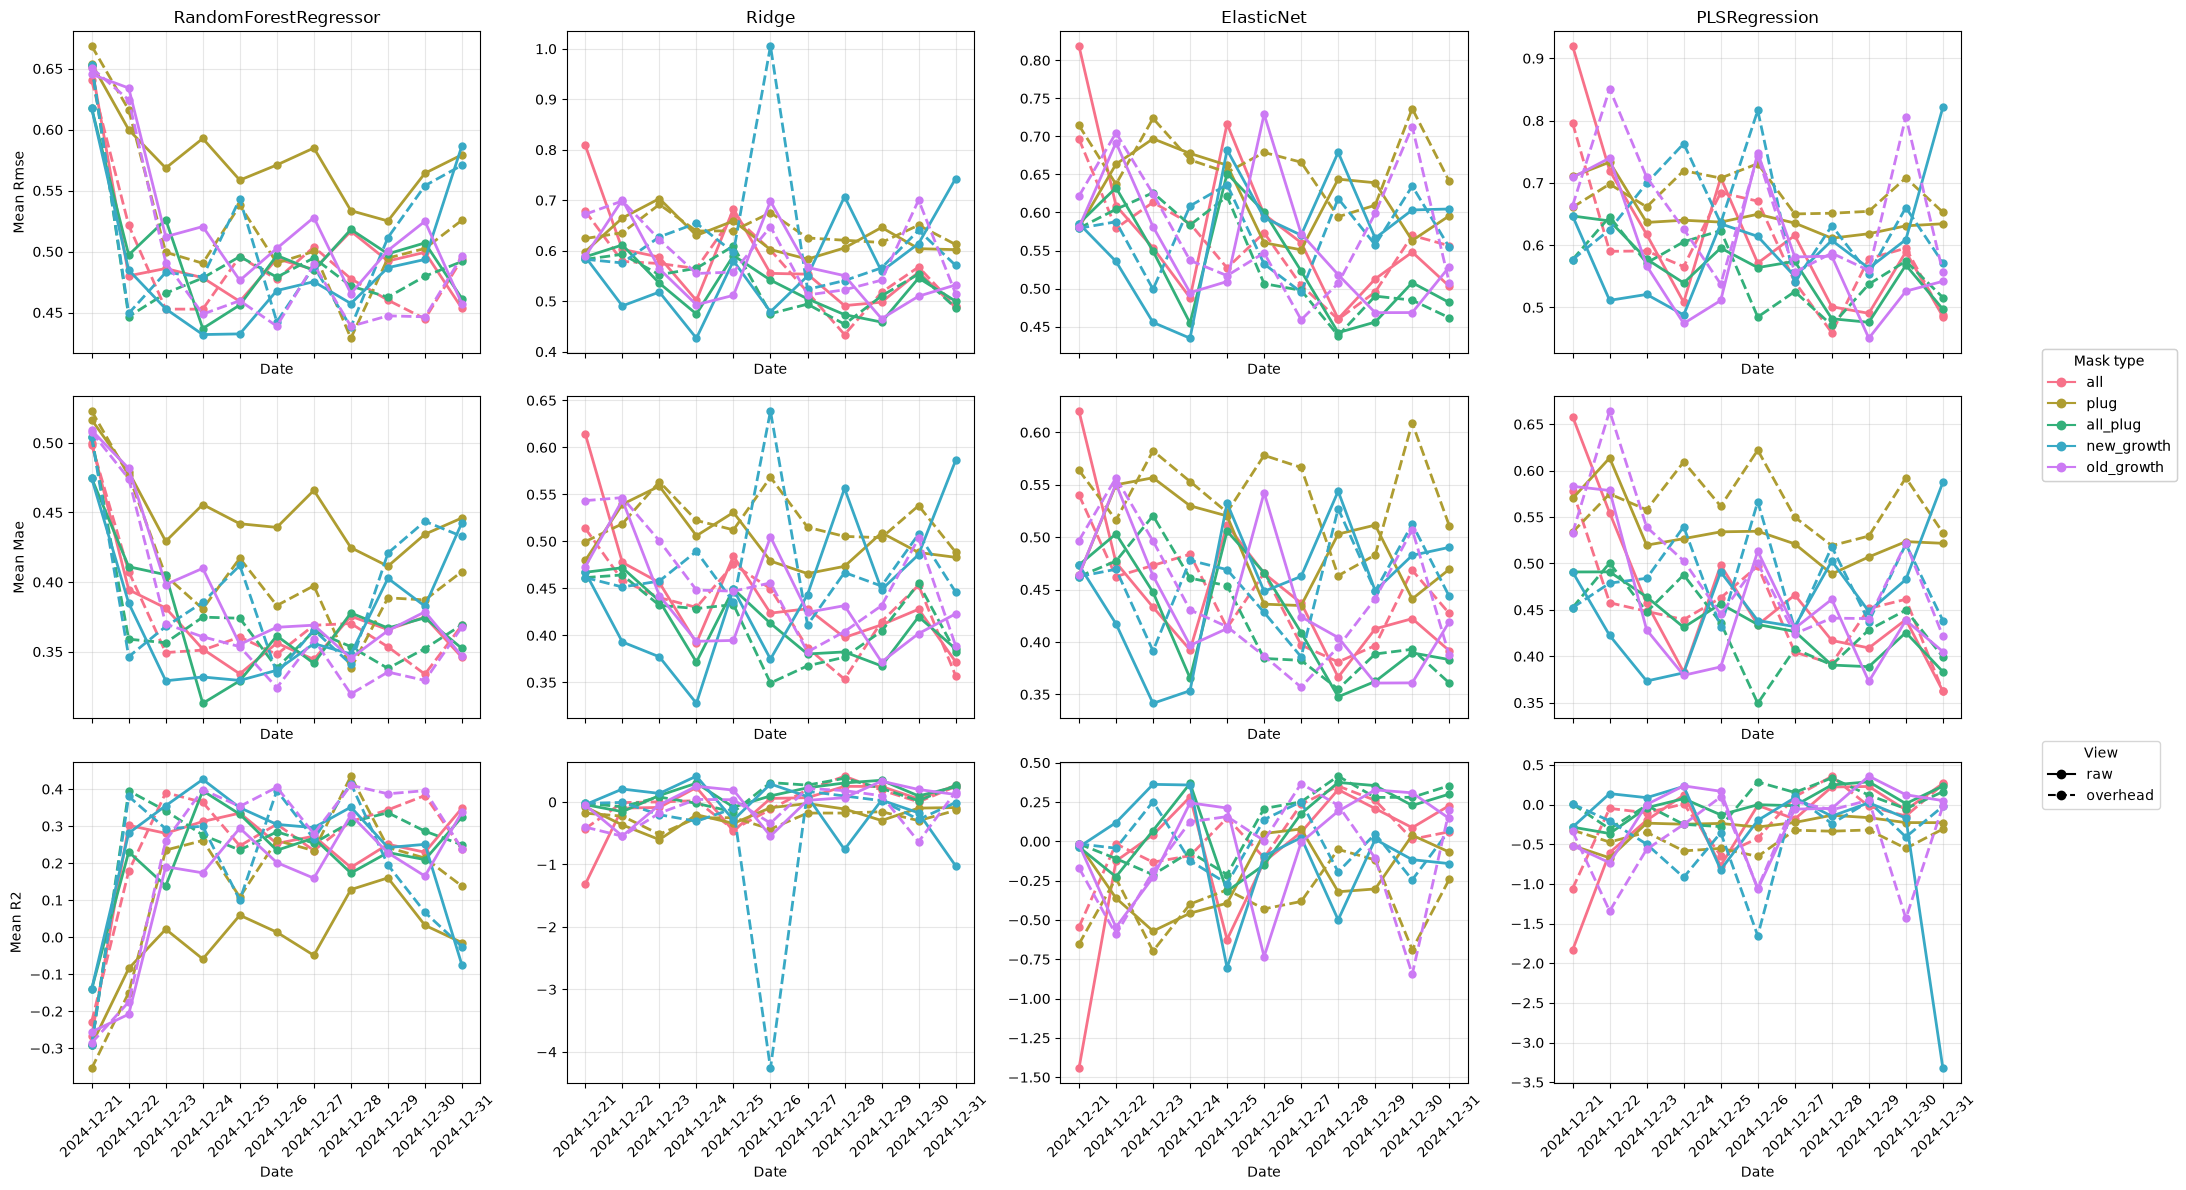

In [15]:
mask_order = ["all", "plug", "all_plug", "new_growth", "old_growth"]
mask_palette = dict(zip(mask_order, sns.color_palette("husl", len(mask_order))))

view_order = ["raw", "overhead"]
view_linestyles = {"raw": "-", "overhead": "--"}

models = df_scores_resp_1["model"].unique()
metrics = df_scores_resp_1.columns[df_scores_resp_1.columns.str.startswith("mean_")] 

n_rows = len(metrics)
n_cols = len(models)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(5*n_cols, 4*n_rows),
    sharex=True
)

if n_rows == 1:
    axes = [axes]
if n_cols == 1:
    axes = [[ax] for ax in axes]

for i, metric in enumerate(metrics):
    for j, model in enumerate(models):

        ax = axes[i][j]

        subset = df_scores_resp_1[df_scores_resp_1["model"] == model]

        for mask_type in mask_order:
            mask_subset = subset[subset["mask_type"] == mask_type]

            for view in view_order:
                view_subset = mask_subset[mask_subset["view"] == view]

                if not view_subset.empty:
                    view_subset = view_subset.sort_values("date")

                    ax.plot(
                        view_subset["date"],
                        view_subset[metric],
                        marker="o",
                        color=mask_palette[mask_type],
                        linestyle=view_linestyles[view],
                        linewidth=2,
                        markersize=5
                    )

        if i == 0:
            ax.set_title(model)

        if j == 0:
            ax.set_ylabel(metric.replace("_", " ").title())
        else:
            ax.set_ylabel("")

        ax.set_xlabel("Date")
        ax.tick_params(axis='x', rotation=45)
        ax.grid(True, alpha=0.3)

mask_legend = [
    Line2D([0], [0],
           color=mask_palette[m],
           linestyle='-',
           marker='o',
           label=m)
    for m in mask_order
]

view_legend = [
    Line2D([0], [0],
           color='black',
           linestyle=view_linestyles[v],
           marker='o',
           label=v)
    for v in view_order
]

legend1 = fig.legend(
    handles=mask_legend,
    loc="center left",
    bbox_to_anchor=(1.02, 0.65),
    title="Mask type"
)

legend2 = fig.legend(
    handles=view_legend,
    loc="center left",
    bbox_to_anchor=(1.02, 0.35),
    title="View"
)

fig.add_artist(legend1)

plt.tight_layout()
plt.show()

In [16]:
0.95 ** 50

0.07694497527671315

### Show the data in each fold using one data subset

In [17]:
df_scores_resp_sub = results_resp_1.get(("raw",'new_growth','2024-12-24'),None)


In [18]:
# Read test_plates_folds_df and update test_plates_folds
test_plates_folds_df = pd.read_csv('../results/test_plates_folds.csv')
test_plates_folds = [test_plates_folds_df[test_plates_folds_df['fold'] == fold]['plate']
                     for fold in sorted(test_plates_folds_df['fold'].unique())]
print("Updated test_plates_folds from saved dataframe")


Updated test_plates_folds from saved dataframe


In [19]:
fold_ids = np.array(test_plates_folds_df['fold'])
fold_ids

array([0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3,
       3, 3, 4, 4, 4, 4, 4])

In [20]:
df_scores_resp_sub

({'ElasticNet':    fold      rmse       mae        r2  best_reg__alpha  best_reg__l1_ratio
  0     1  0.384267  0.306155  0.568406         0.187382                 0.9
  1     2  0.759472  0.612197 -0.531143         0.023101                 0.9
  2     3  0.412574  0.337541  0.593605         0.187382                 0.5
  3     4  0.303282  0.249466  0.761648         0.065793                 0.9
  4     5  0.314093  0.262274  0.398084         0.065793                 0.9,
  'Ridge':    fold      rmse       mae        r2  best_reg__alpha
  0     1  0.375129  0.277219  0.588689        31.622777
  1     2  0.691478  0.492293 -0.269252        31.622777
  2     3  0.379183  0.326318  0.656725        10.000000
  3     4  0.412691  0.296400  0.558660       100.000000
  4     5  0.274914  0.246520  0.538882       100.000000,
  'PLSRegression':    fold      rmse       mae        r2  best_pls__n_components
  0     1  0.398089  0.307683  0.536799                       2
  1     2  0.816082  0.625

In [21]:
fold_ids = np.array(test_plates_folds_df['fold'])+1

y_inf_all_best = []
for model, summ in df_scores_resp_sub[1].items():
    print(f"Model: {model}")
    y_inf = pd.DataFrame({
        "model": model,
        "y_true": np.asarray(summ["y_true_all"]).flatten(),
        "y_pred": np.asarray(summ["y_pred_all"]).flatten(),
        "fold": fold_ids
    })
    y_inf_all_best.append(y_inf)
y_inf_all_best_df = pd.concat(y_inf_all_best, ignore_index=True)


Model: ElasticNet
Model: Ridge
Model: PLSRegression
Model: RandomForestRegressor


In [22]:
r2_mean_dict = {}
for model, summ in df_scores_resp_sub[1].items():
    r2_mean_dict[model] = summ['mean_r2']

r2_folds_dict = {
    model: summ.set_index("fold")["r2"].to_dict()
    for model, summ in df_scores_resp_sub[0].items()
}

In [23]:
y_inf_all_best_df.head()

,model,y_true,y_pred,fold
0,ElasticNet,1.796258,1.928331,1
1,ElasticNet,1.974610,1.857011,1
2,ElasticNet,2.219146,2.022165,1
3,ElasticNet,2.735729,2.154061,1
4,ElasticNet,1.513399,1.643266,1


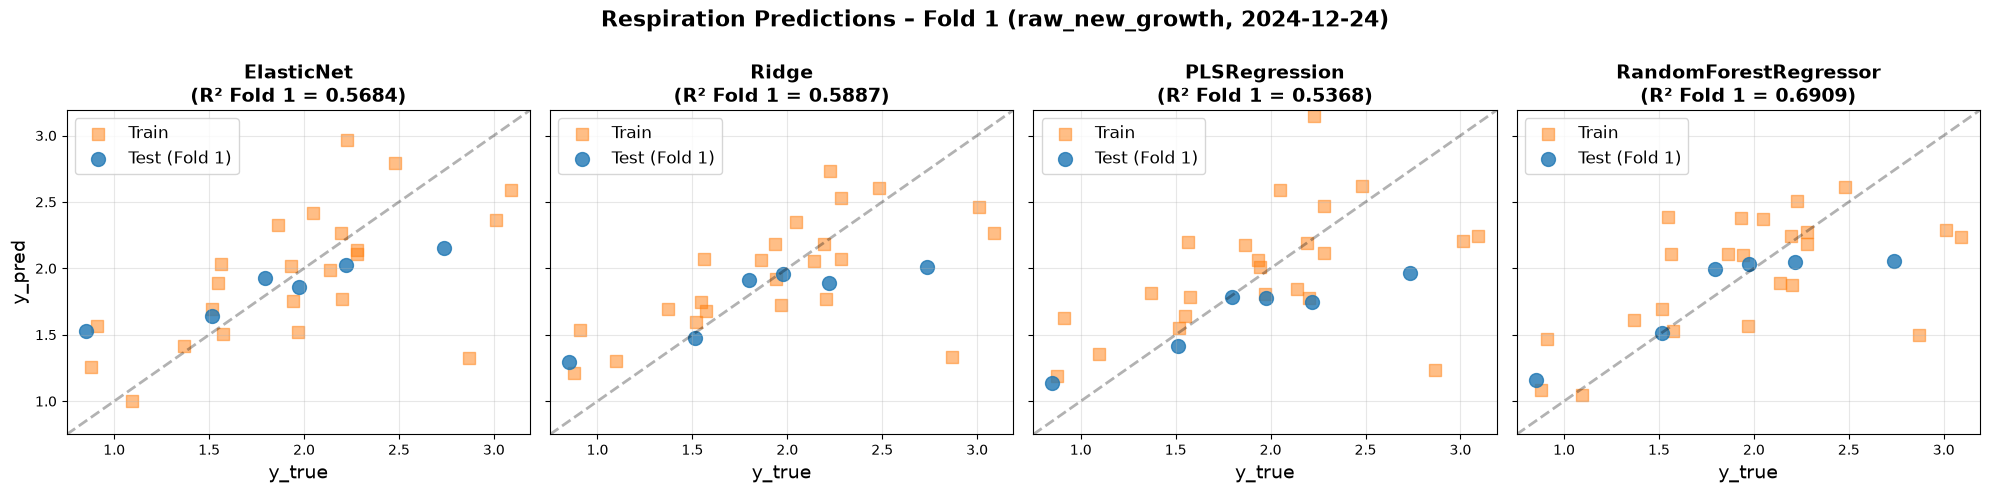

In [24]:

FONTSIZE = 14
model_order = ["ElasticNet", "Ridge", "PLSRegression", "RandomForestRegressor"]
models_unique = [m for m in model_order if m in y_inf_all_best_df["model"].unique()]
n_models = len(models_unique)

fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 5), sharey=True, sharex=True)
if n_models == 1:
    axes = [axes]

for idx, model in enumerate(models_unique):
    ax = axes[idx]
    model_data = y_inf_all_best_df[y_inf_all_best_df["model"] == model]

    # Training data: folds 2-5 (samples that were training data for fold 1's model)
    train_data = model_data[model_data["fold"] != 1]
    ax.scatter(
        train_data["y_true"],
        train_data["y_pred"],
        label="Train",
        alpha=0.5,
        s=80,
        color="tab:orange",
        marker="s"
    )

    # Test data: fold 1 only
    test_data = model_data[model_data["fold"] == 1]
    ax.scatter(
        test_data["y_true"],
        test_data["y_pred"],
        label="Test (Fold 1)",
        alpha=0.8,
        s=100,
        color="tab:blue"
    )

    # Add diagonal line (perfect predictions)
    all_vals = np.concatenate([model_data["y_true"].values, model_data["y_pred"].values])
    lims = [all_vals.min() - 0.1, all_vals.max() + 0.1]
    ax.plot(lims, lims, "k--", alpha=0.3, linewidth=2)
    ax.set_xlim(lims)
    ax.set_ylim(lims)

    ax.legend(loc="upper left", frameon=True, fontsize=FONTSIZE - 2)

    # Fold 1 R² in title
    r2_fold1 = r2_folds_dict[model].get(1, float("nan"))
    r2_str = f"{r2_fold1:.4f}" if pd.notnull(r2_fold1) else "NA"
    ax.set_xlabel("y_true", fontsize=FONTSIZE)
    ax.set_title(f"{model}\n(R² Fold 1 = {r2_str})", fontsize=FONTSIZE, fontweight="bold")
    ax.grid(True, alpha=0.3)

    if idx == 0:
        ax.set_ylabel("y_pred", fontsize=FONTSIZE)

fig.suptitle("Respiration Predictions – Fold 1 (raw_new_growth, 2024-12-24)", fontsize=FONTSIZE + 2, fontweight="bold", y=1.00)
plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.show()


### get the result from one fold

In [25]:
# Extract fold 1 R² values for each model across all elements in results_resp_2
r2_fold2_results = []

for (view, mask_type, date), v in results_resp_1.items():
    # v[0] contains per-fold results
    fold_results = v[0]
    
    for model, summ in fold_results.items():
        # summ is a dataframe with fold and r2 columns
        fold_2_data = summ[summ["fold"] == 1]
        
        if not fold_2_data.empty:
            r2_value = fold_2_data["r2"].values[0]
        else:
            r2_value = None
        
        r2_fold2_results.append({
            "view": view,
            "mask_type": mask_type,
            "date": date,
            "model": model,
            "r2_fold2": r2_value
        })

# Create dataframe from results
r2_fold2_df = pd.DataFrame(r2_fold2_results)



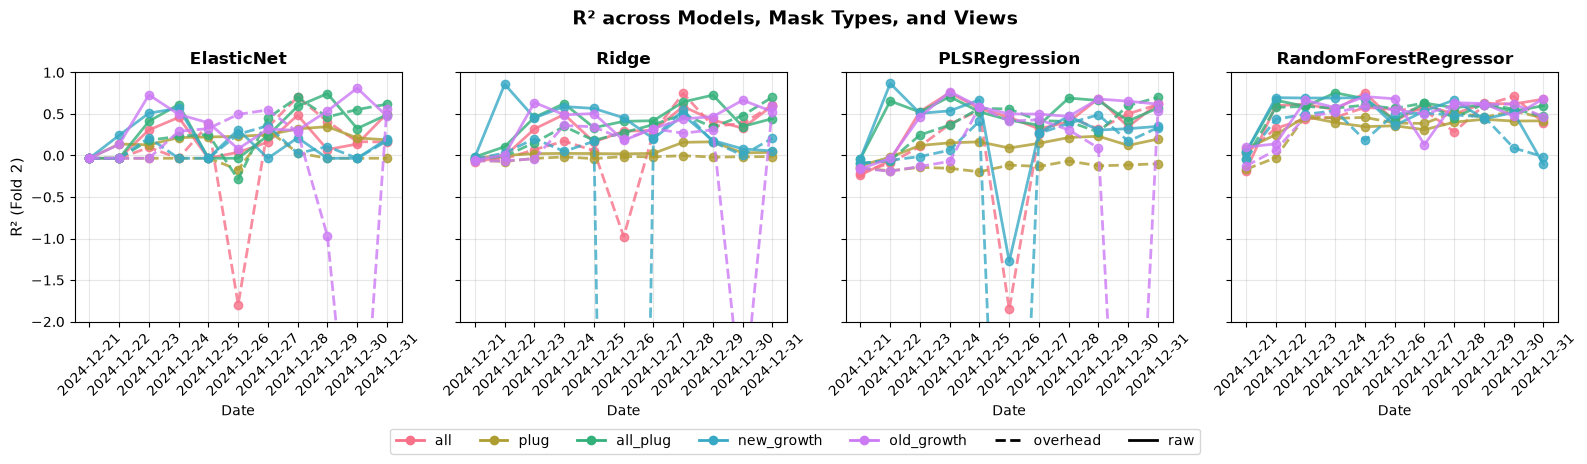

In [26]:
# Plot fold 2 R² values with 4 subplots (one for each model)
model_order = ["ElasticNet", "Ridge", "PLSRegression", "RandomForestRegressor"]
models = [m for m in model_order if m in r2_fold2_df["model"].unique()]

#mask_types = sorted(r2_fold2_df["mask_type"].unique())
mask_types = r2_fold2_df["mask_type"].unique()

views = r2_fold2_df["view"].unique()

# Define color palette for mask types
mask_palette = dict(zip(mask_types, sns.color_palette("husl", len(mask_types))))

# Define line styles for views
view_linestyles = {"raw": "-", "overhead": "--"}

fig, axes = plt.subplots(1, len(models), figsize=(16, 4), sharey=True)

for idx, model in enumerate(models):
    ax = axes[idx]
    model_data = r2_fold2_df[r2_fold2_df["model"] == model]
    
    # Sort by date for proper line plotting
    model_data = model_data.sort_values("date")
    
    # Plot each combination of view and mask_type as a line
    for mask_type in mask_types:
        mask_data = model_data[model_data["mask_type"] == mask_type]
        
        for view in views:
            view_data = mask_data[mask_data["view"] == view]
            
            if not view_data.empty:
                ax.plot(
                    view_data["date"],
                    view_data["r2_fold2"],
                    color=mask_palette[mask_type],
                    linestyle=view_linestyles[view],
                    marker='o',
                    markersize=6,
                    linewidth=2,
                    alpha=0.8,
                    label=f"{mask_type}-{view}"
                )
    
    ax.set_title(model, fontsize=12, fontweight="bold")
    ax.set_xlabel("Date")
    ax.set_ylim(-2, 1)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("R² (Fold 2)", fontsize=11)

# Create custom legend
mask_handles = [
    plt.Line2D([0], [0], color=mask_palette[m], linestyle='-', marker='o', markersize=6, linewidth=2, label=m)
    for m in mask_types
]

view_handles = [
    plt.Line2D([0], [0], 
               color='black', 
               linestyle=view_linestyles[v], 
               marker='',        # ← remove marker so linestyle is prominent
               markersize=6, 
               linewidth=2, 
               label=v)
    for v in views
]

fig.legend(
    handles=mask_handles + view_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.05),
    ncol=len(mask_types) + len(views),
    frameon=True
)

fig.suptitle("R² across Models, Mask Types, and Views", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.subplots_adjust(bottom=0.2)
plt.show()


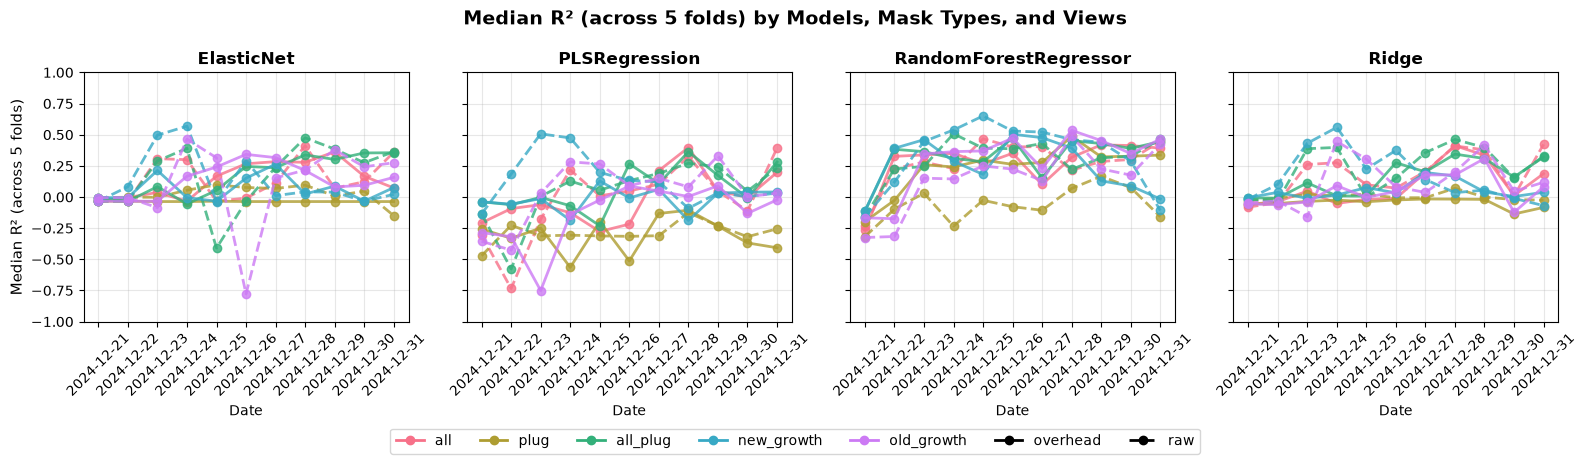

In [27]:
# Extract median R² values across all 5 folds for each model
r2_median_results = []

for (view, mask_type, date), v in results_resp_1.items():
    # v[0] contains per-fold results
    fold_results = v[0]
    
    for model, summ in fold_results.items():
        # summ is a dataframe with fold and r2 columns
        # Calculate median R² across all folds
        r2_values = summ["r2"].values
        median_r2 = np.median(r2_values)
        
        r2_median_results.append({
            "view": view,
            "mask_type": mask_type,
            "date": date,
            "model": model,
            "r2_median": median_r2
        })

# Create dataframe from results
r2_median_df = pd.DataFrame(r2_median_results)

# Plot median R² values with 4 subplots (one for each model)
models = sorted(r2_median_df["model"].unique())
#mask_types = sorted(r2_median_df["mask_type"].unique())
mask_types = r2_median_df["mask_type"].unique()
views = sorted(r2_median_df["view"].unique())

# Define color palette for mask types
mask_palette = dict(zip(mask_types, sns.color_palette("husl", len(mask_types))))

# Define line styles for views
view_linestyles = {view: linestyle for view, linestyle in zip(views, ['-', '--', '-.', ':'])}

fig, axes = plt.subplots(1, len(models), figsize=(16, 4), sharey=True)

for idx, model in enumerate(models):
    ax = axes[idx]
    model_data = r2_median_df[r2_median_df["model"] == model]
    
    # Sort by date for proper line plotting
    model_data = model_data.sort_values("date")
    
    # Plot each combination of view and mask_type as a line
    for mask_type in mask_types:
        mask_data = model_data[model_data["mask_type"] == mask_type]
        
        for view in views:
            view_data = mask_data[mask_data["view"] == view]
            
            if not view_data.empty:
                ax.plot(
                    view_data["date"],
                    view_data["r2_median"],
                    color=mask_palette[mask_type],
                    linestyle=view_linestyles[view],
                    marker='o',
                    markersize=6,
                    linewidth=2,
                    alpha=0.8,
                    label=f"{mask_type}-{view}"
                )
    
    ax.set_title(model, fontsize=12, fontweight="bold")
    ax.set_xlabel("Date")
    ax.set_ylim(-1, 1)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Median R² (across 5 folds)", fontsize=11)

# Create custom legend
mask_handles = [
    plt.Line2D([0], [0], color=mask_palette[m], linestyle='-', marker='o', markersize=6, linewidth=2, label=m)
    for m in mask_types
]

view_handles = [
    plt.Line2D([0], [0], color='black', linestyle=view_linestyles[v], marker='o', markersize=6, linewidth=2, label=v)
    for v in views
]

fig.legend(
    handles=mask_handles + view_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.05),
    ncol=len(mask_types) + len(views),
    frameon=True
)

fig.suptitle("Median R² (across 5 folds) by Models, Mask Types, and Views", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.subplots_adjust(bottom=0.2)
plt.show()


In [28]:
mask_types

array(['all', 'plug', 'all_plug', 'new_growth', 'old_growth'],
      dtype=object)

In [31]:
r2_median_df["mask_type"].unique()

array(['all', 'plug', 'all_plug', 'new_growth', 'old_growth'],
      dtype=object)

## Feature importance for one dataset (5CV)

#### an example for one dataset raw_all_24


In [39]:
importance_1data = pd.read_csv("../results/cluster_importance_results_raw_all_24.csv")

In [40]:
importance_1data.head()

,feature_name,cluster,mean_importance,std_importance
0,R_8bit_median,12,0.403326,0.456203
1,V_median,12,0.403326,0.456203
2,area_pixels,19,0.116513,0.154998
3,min_width,19,0.116513,0.154998
4,max_width,19,0.116513,0.154998


In [41]:
for group in importance_1data['cluster'].unique():
    print(f"for cluster {group}")
    print(importance_1data[importance_1data["cluster"]==group]["feature_name"])

for cluster 12
0    R_8bit_median
1         V_median
Name: feature_name, dtype: object
for cluster 19
2    area_pixels
3      min_width
4      max_width
5         H_mean
6      hull_area
7      perimeter
Name: feature_name, dtype: object
for cluster 11
8    rect_angle_deg
Name: feature_name, dtype: object
for cluster 13
9             S_median
10            L_median
11       B_8bit_median
12    Gray_8bit_median
13       G_8bit_median
Name: feature_name, dtype: object
for cluster 6
14            S_var
15    Gray_8bit_var
16            L_var
17       R_8bit_var
18            V_var
19            A_var
20       B_8bit_var
21       G_8bit_var
Name: feature_name, dtype: object
for cluster 8
22       G_8bit_mean
23    Gray_8bit_mean
24       B_8bit_mean
25            S_mean
26            L_mean
Name: feature_name, dtype: object
for cluster 10
27    LabB_median
28      LabB_mean
Name: feature_name, dtype: object
for cluster 5
29    A_mean
30     H_var
31     A_min
Name: feature_name, dtype: obj

In [42]:
def plot_feature_importance_with_cluster_markers(importance_df, trait_order, save_path=None):
    # 1. Reorder based on your specific trait vector
    plot_df = importance_df.set_index('feature_name').loc[trait_order].reset_index()

    # 2. Setup figure
    plt.figure(figsize=(6, 18))
    sns.set_style("whitegrid")

    # 3. Create Barplot (Color by cluster)
    ax = sns.barplot(
        data=plot_df,
        x="mean_importance",
        y="feature_name",
        hue="cluster",
        palette="tab20",
        dodge=False,
        alpha=0.5,     # Slightly transparent bars to make markers/CI pop
        legend=False
    )

    # 4. Add the Error Bars (CI)
    # We add 'fmt="."' to put a small point at the mean, 
    # but we will overlay a better one next.
    plt.errorbar(
        x=plot_df["mean_importance"], 
        y=np.arange(len(plot_df)), 
        xerr=plot_df["std_importance"], 
        fmt='none', 
        c='black', 
        capsize=4,
        elinewidth=1.2,
        alpha=0.8
    )

    # 5. ⭐ ADD THE MEAN LINE/MARKER IN THE MIDDLE
    # We use a scatter plot to place a distinct white-filled diamond or circle
    # exactly at the mean importance value for each feature.
    plt.scatter(
        x=plot_df["mean_importance"],
        y=np.arange(len(plot_df)),
        marker='d',          # Diamond marker
        color='white',       # Contrast against the bar
        edgecolors='black',  # Outline for visibility
        s=40,                # Size
        zorder=5             # Ensure it sits on top of everything
    )

    # 6. Formatting
    plt.axvline(x=0, color='red', linestyle='-', linewidth=1.5, alpha=0.8) # Baseline
    plt.title("Cluster-Based Feature Importance (CVPFI-C)\nMean Importance marked with $\diamond$", fontsize=16)
    plt.xlabel("Mean Importance (Drop in $R^2$)", fontsize=13)
    plt.ylabel("Features (Ranked by Trait)", fontsize=13)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

# 

<>:50: SyntaxWarning: invalid escape sequence '\d'
<>:50: SyntaxWarning: invalid escape sequence '\d'
/var/folders/0r/r2dplk4d72d437ygr7ycq8kw0000gn/T/ipykernel_82391/930135689.py:50: SyntaxWarning: invalid escape sequence '\d'
  plt.title("Cluster-Based Feature Importance (CVPFI-C)\nMean Importance marked with $\diamond$", fontsize=16)


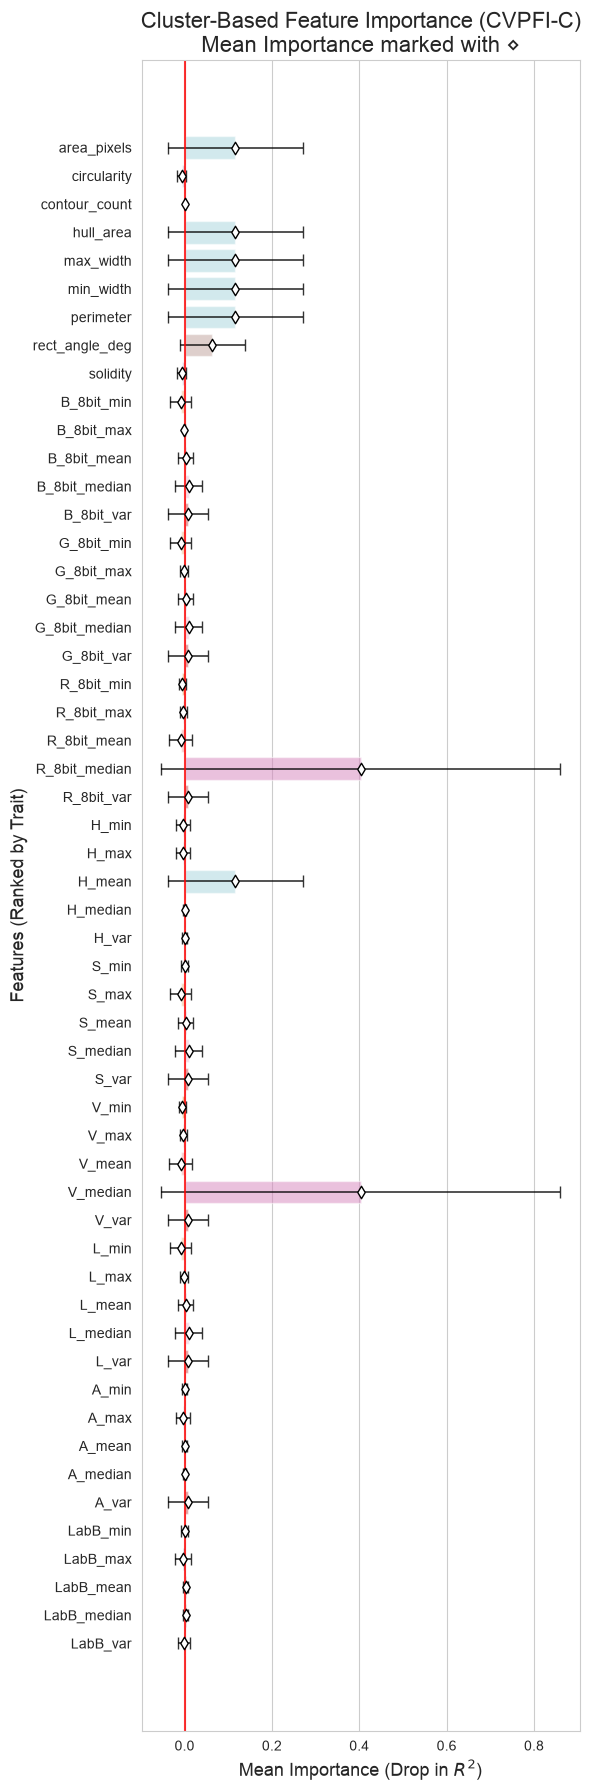

In [43]:
### plot feature importance for raw_all_2024-12-24
plot_feature_importance_with_cluster_markers(importance_1data, trait_order)